# simulate GARCH model

In [20]:
omega= 0.001 # baseline variance
alpha =0.05 # effect of last squared return
beta = 0.94 # effect of last variance
n= 1000 # number of steps

returns =np.zeros(n)
sigma2= np.zeros(n)

sigma2[0]=omega/(1-alpha - beta) # initial unconditional variance
sigma= np.sqrt(sigma2[0])
np.random.seed(42)

In [21]:
for t in range(1,n):
    z=np.random.normal()
    returns[t]= sigma*z
    sigma2[t]= omega + alpha*(returns[t]**2)+ beta*sigma2[t-1]
    sigma = np.sqrt(sigma2[t])


Assume zero mean and i.i.d. standard normal shocks:

$$
r_t = \sigma_t z_t,\quad z_t \sim \mathcal{N}(0,1).
$$

Conditional variance dynamics:

$$
\sigma_t^2 = \omega + \alpha\, r_{t-1}^2 + \beta\, \sigma_{t-1}^2.
$$

* \$\omega\$ — baseline variance
* \$\alpha\$ — sensitivity to last period’s shock
* \$\beta\$ — persistence of last period’s variance

**Unconditional (long-run) variance** exists when \$\alpha+\beta<1\$ and equals

$$
\mathbb{E}[\sigma_t^2] \;=\; \frac{\omega}{1-\alpha-\beta}.
$$



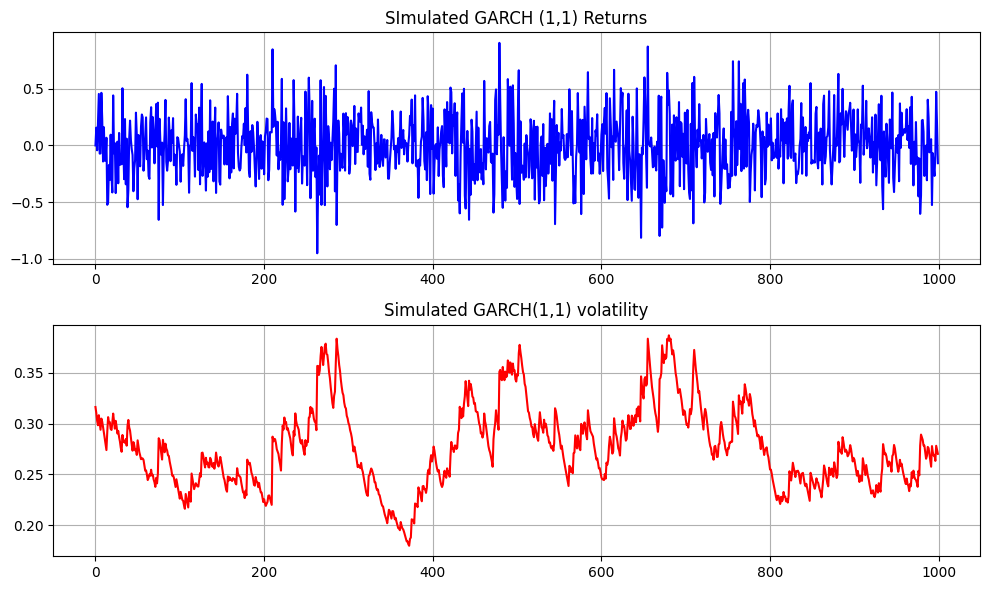

In [22]:
fig , ax = plt.subplots(2,1, figsize= (10,6), sharex= False)
ax[0].plot( returns , color= 'blue')
ax[0].set_title ("SImulated GARCH (1,1) Returns")
ax[0].grid(True)
ax[1].plot(np.sqrt(sigma2), color='red')
ax[1].set_title('Simulated GARCH(1,1) volatility')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# simulate Heston Lite

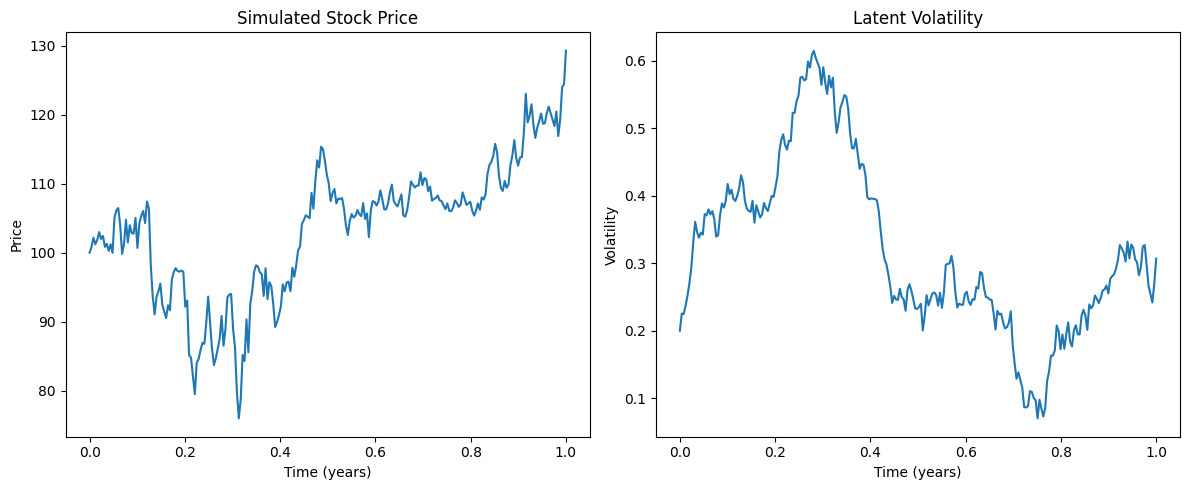

In [23]:
dt = 1/250
T = 1 
N = int(T/dt)
mu = 0.05
kappa = 2.0
theta = 0.04
xi = 0.3
S0 = 100
sigma0 = 0.2


time = np.linspace(0, T, N)
S = np.zeros(N)
sigma = np.zeros(N)

S[0] = S0
sigma[0] = sigma0

# Simulation using Euler-Maruyama
for t in range(1, N):
    dW_S = np.random.normal(0, np.sqrt(dt))
    dW_sigma = np.random.normal(0, np.sqrt(dt))
    
    sigma[t] = np.abs(sigma[t-1] + kappa*(theta - sigma[t-1])*dt + xi*dW_sigma)  # keep positive
    S[t] = S[t-1] + mu*S[t-1]*dt + sigma[t]*S[t-1]*dW_S

# Plot results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(time, S)
plt.title('Simulated Stock Price')
plt.xlabel('Time (years)')
plt.ylabel('Price')

plt.subplot(1,2,2)
plt.plot(time, sigma)
plt.title('Latent Volatility')
plt.xlabel('Time (years)')
plt.ylabel('Volatility')

plt.tight_layout()
plt.show()


 # simulate hestone lite using actual crypto prices

In [52]:
for filename in os.listdir():
    if filename.endswith('.csv'):
        print(filename)

BNB_spot_full.csv
BTC_spot_full.csv
ETH_spot_full.csv
TRX_spot_full.csv
XRP_spot_full.csv


In [53]:
df=pd.read_csv('BTC_spot_full.csv')

In [54]:
df.head()

,Unnamed: 0,close_time,base,bam_vwa,bam_open,bam_close,bam_high,bam_low,bam_volatility_1m_return,base_volume,pct_buy_volume,annual_interest_rate,spread_1m_vwa_vwa,spread_twa
0,1,2019-04-20 01:00:00,BTC,5264.078218,5257.370,5255.150,5273.850,5254.525,3.576469,422.210461,49.667343,0.36524,0.677842,0.947055
1,6,2019-04-20 02:00:00,BTC,5266.318238,5254.935,5275.525,5285.250,5251.000,5.922756,550.562812,58.754393,0.36524,0.130476,0.845644
2,11,2019-04-20 03:00:00,BTC,5279.507125,5275.665,5273.365,5294.320,5266.070,5.695222,998.755749,59.920083,0.36524,0.225569,1.046440
3,16,2019-04-20 04:00:00,BTC,5271.180558,5273.360,5276.775,5278.965,5261.840,4.039062,536.708433,48.206048,0.36524,0.538942,0.931184
4,21,2019-04-20 05:00:00,BTC,5282.801431,5276.770,5296.015,5297.630,5268.795,7.376661,638.584431,47.474698,0.36524,0.479266,0.919920


In [32]:
df.columns

Index(['Unnamed: 0', 'close_time', 'base', 'bam_vwa', 'bam_open', 'bam_close',
       'bam_high', 'bam_low', 'bam_volatility_1m_return', 'base_volume',
       'pct_buy_volume', 'annual_interest_rate', 'spread_1m_vwa_vwa',
       'spread_twa'],
      dtype='object')

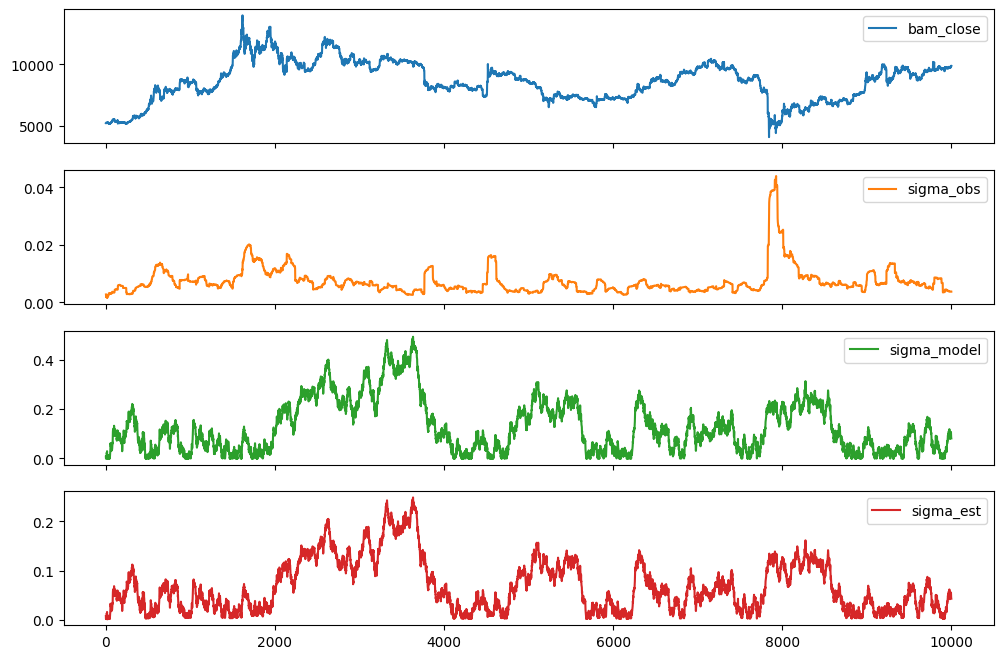

In [55]:

df['return'] = df['bam_close'].pct_change().fillna(0)

# 1️⃣ Rolling-window realized volatility (window = 10 minutes here)
window = 100
df['sigma_obs'] = df['return'].rolling(window=window, min_periods=1).std()
df=df[:10000]
# Heston-lite parameters
kappa = 2.0
theta = df['sigma_obs'].mean()   # long-term mean
xi = 0.3
dt = 1/1440  # assuming 1-minute data
alpha = 0.5

sigma_model = [theta]  # initial volatility
sigma_est = [theta]

for t in range(1, len(df)):
    # stochastic Heston-lite volatility update
    dW = np.random.normal(0, np.sqrt(dt))
    sigma_pred = sigma_model[-1] + kappa*(theta - sigma_model[-1])*dt + xi*dW
    sigma_pred = max(sigma_pred, 1e-6)  # keep positive
    sigma_model.append(sigma_pred)
    
    # naive DA: weighted average
    sigma_new = alpha*sigma_pred + (1-alpha)*df['sigma_obs'].iloc[t]
    sigma_est.append(sigma_new)

df['sigma_model'] = sigma_model
df['sigma_est'] = sigma_est

# plot results
df[['bam_close', 'sigma_obs', 'sigma_model', 'sigma_est']].plot(subplots=True, figsize=(12,8))
plt.show()


In [56]:
def compute_rolling_volatility(returns, window=100):
    """Compute rolling-window realized volatility."""
    return returns.rolling(window=window, min_periods=1).std()

def naive_DA(sigma_obs, kappa=2.0, theta=None, xi=0.3, dt=1/1440, alpha=0.5):
    """Naive Data Assimilation using Heston-lite stochastic volatility model."""
    if theta is None:
        theta = sigma_obs.mean()
    sigma_model = [theta]
    sigma_est = [theta]

    for t in range(1, len(sigma_obs)):
        # stochastic Heston-lite volatility update
        dW = np.random.normal(0, np.sqrt(dt))
        sigma_pred = sigma_model[-1] + kappa*(theta - sigma_model[-1])*dt + xi*dW
        sigma_pred = max(sigma_pred, 1e-6)
        sigma_model.append(sigma_pred)

        # naive DA: weighted average
        sigma_new = alpha*sigma_pred + (1-alpha)*sigma_obs.iloc[t]
        sigma_est.append(sigma_new)

    return sigma_model, sigma_est



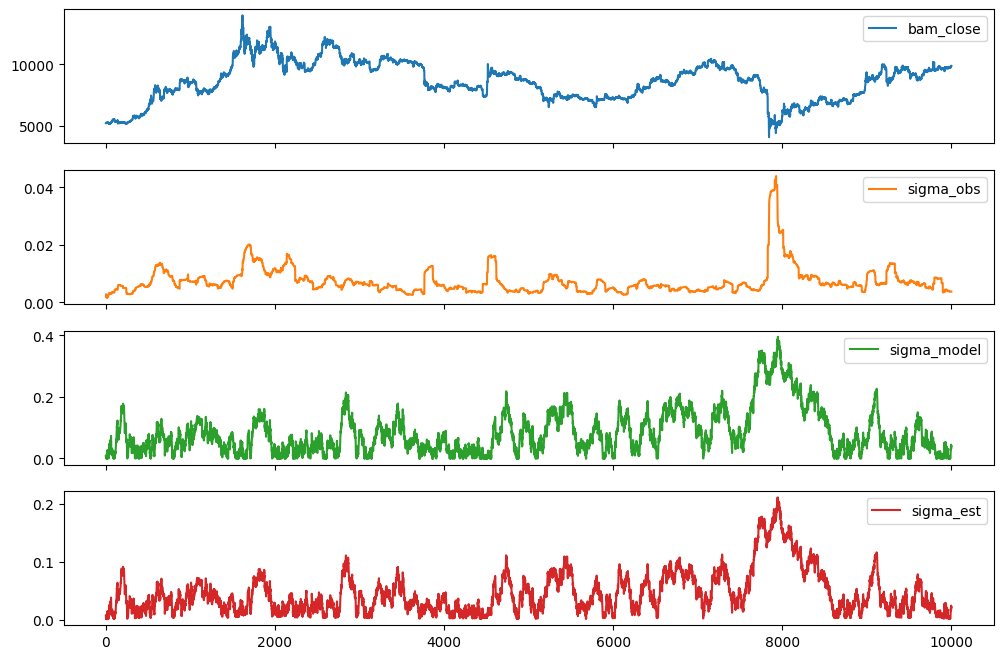

In [57]:

df['return'] = df['bam_close'].pct_change().fillna(0)

df['sigma_obs'] = compute_rolling_volatility(df['return'], window=100)
 
df = df[:10000]

# Apply naive DA
sigma_model, sigma_est = naive_DA(df['sigma_obs'])
df['sigma_model'] = sigma_model
df['sigma_est'] = sigma_est

# Plot results
df[['bam_close', 'sigma_obs', 'sigma_model', 'sigma_est']].plot(subplots=True, figsize=(12,8))
plt.show()

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_rolling_volatility(returns, window=100):
    """Compute rolling-window realized volatility."""
    return returns.rolling(window=window, min_periods=1).std()

def heston_predictor(sigma_prev, theta, kappa=2.0, xi=0.3, dt=1/1440):
    """Heston-lite stochastic volatility predictor."""
    dW = np.random.normal(0, np.sqrt(dt))
    sigma_pred = sigma_prev + kappa*(theta - sigma_prev)*dt + xi*dW
    return max(sigma_pred, 1e-6)

def generic_DA(sigma_obs, predictor, combiner, theta=None):
    """Generic data assimilation framework.
    predictor: function(sigma_prev, theta) -> sigma_model_new
    combiner: function(sigma_model_new, sigma_obs_t) -> sigma_est_t
    """
    if theta is None:
        theta = sigma_obs.mean()

    sigma_model = [theta]
    sigma_est = [theta]

    for t in range(1, len(sigma_obs)):
        sigma_pred = predictor(sigma_model[-1], theta)
        sigma_model.append(sigma_pred)
        sigma_new = combiner(sigma_pred, sigma_obs.iloc[t])
        sigma_est.append(sigma_new)

    return sigma_model, sigma_est

def naive_combiner(sigma_pred, sigma_obs_t, alpha=0.5):
    return alpha*sigma_pred + (1-alpha)*sigma_obs_t




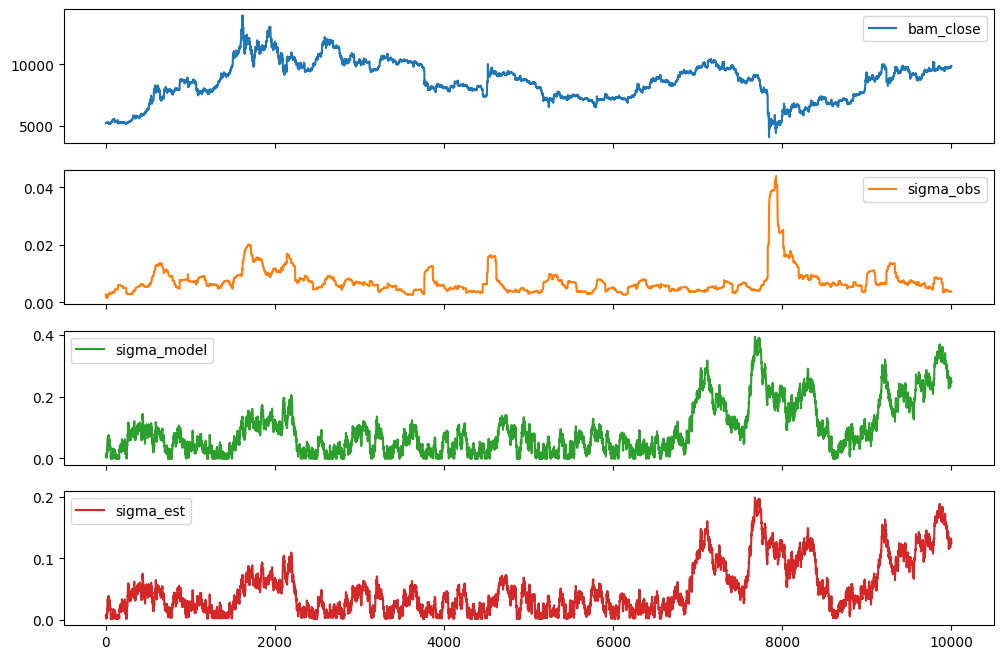

In [59]:
df['return'] = df['bam_close'].pct_change().fillna(0)

# Compute rolling-window volatility
df['sigma_obs'] = compute_rolling_volatility(df['return'], window=100)

# Limit data for testing
df = df[:10000]

# Apply generic DA with naive combiner
sigma_model, sigma_est = generic_DA(df['sigma_obs'], predictor=heston_predictor, combiner=naive_combiner)
df['sigma_model'] = sigma_model
df['sigma_est'] = sigma_est

# Plot results
df[['bam_close', 'sigma_obs', 'sigma_model', 'sigma_est']].plot(subplots=True, figsize=(12,8))
plt.show()

In [60]:
def kalman_DA(sigma_obs, theta=None, kappa=2.0, xi=0.3, dt=1/1440, R=1e-4, Q=1e-5):
    """Kalman Filter based Data Assimilation."""
    if theta is None:
        theta = sigma_obs.mean()

    sigma_est = [theta]
    P = 1.0  # initial estimation error covariance

    for t in range(1, len(sigma_obs)):
        # prediction
        sigma_pred = sigma_est[-1] + kappa*(theta - sigma_est[-1])*dt
        P_pred = P + Q

        # update
        K = P_pred / (P_pred + R)
        sigma_new = sigma_pred + K * (sigma_obs.iloc[t] - sigma_pred)
        P = (1 - K) * P_pred

        sigma_est.append(sigma_new)

    sigma_model = [theta] + [theta + kappa*(theta - theta)*dt for _ in range(1, len(sigma_obs))]  # placeholder
    return sigma_model, sigma_est

In [61]:
def particle_filter_DA(sigma_obs, theta=None, kappa=2.0, xi=0.3, dt=1/1440, N_particles=100, alpha=0.5):
    """Particle Filter based Data Assimilation."""
    if theta is None:
        theta = sigma_obs.mean()

    particles = np.full(N_particles, theta)
    sigma_est = [theta]

    for t in range(1, len(sigma_obs)):
        # propagate particles using Heston-lite
        dW = np.random.normal(0, np.sqrt(dt), size=N_particles)
        particles = particles + kappa*(theta - particles)*dt + xi*dW
        particles = np.clip(particles, 1e-6, None)

        # compute weights based on observation likelihood
        obs = sigma_obs.iloc[t]
        weights = np.exp(-0.5*((obs - particles)/0.001)**2)  # small observation noise
        weights /= np.sum(weights)

        # resample
        indices = np.random.choice(np.arange(N_particles), size=N_particles, p=weights)
        particles = particles[indices]

        # estimated state
        sigma_new = np.mean(particles)
        sigma_est.append(sigma_new)

    sigma_model = [theta] + [theta + kappa*(theta - theta)*dt for _ in range(1, len(sigma_obs))]  # placeholder
    return sigma_model, sigma_est

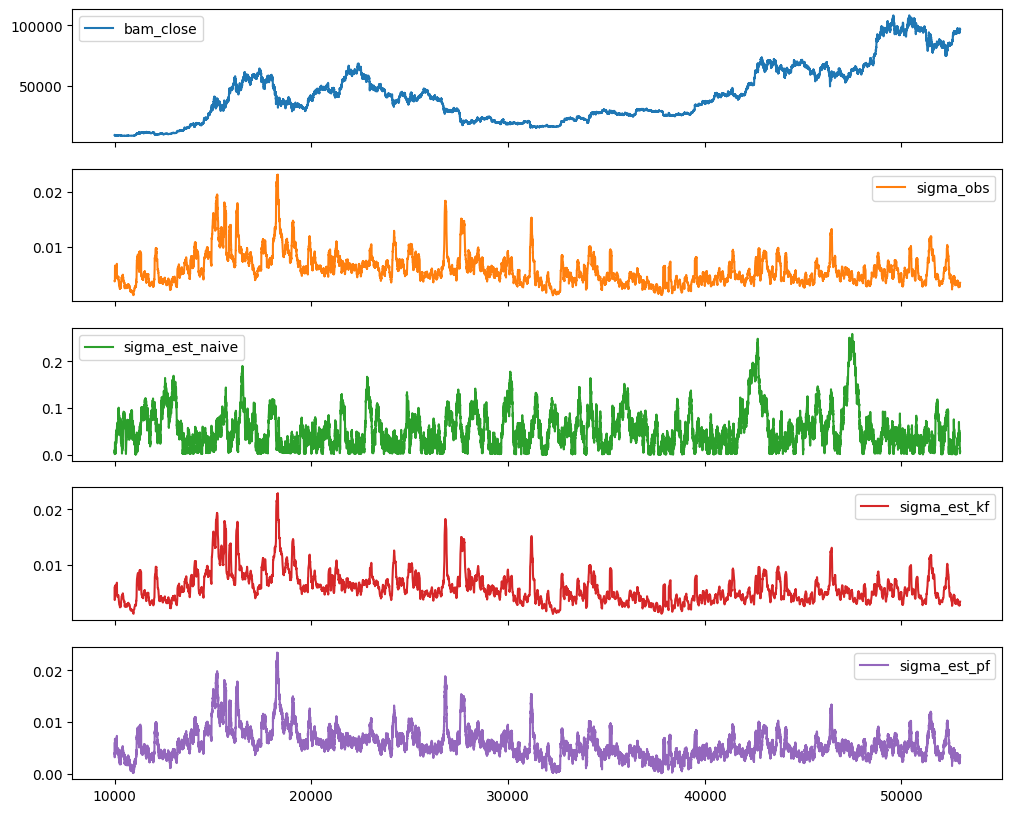

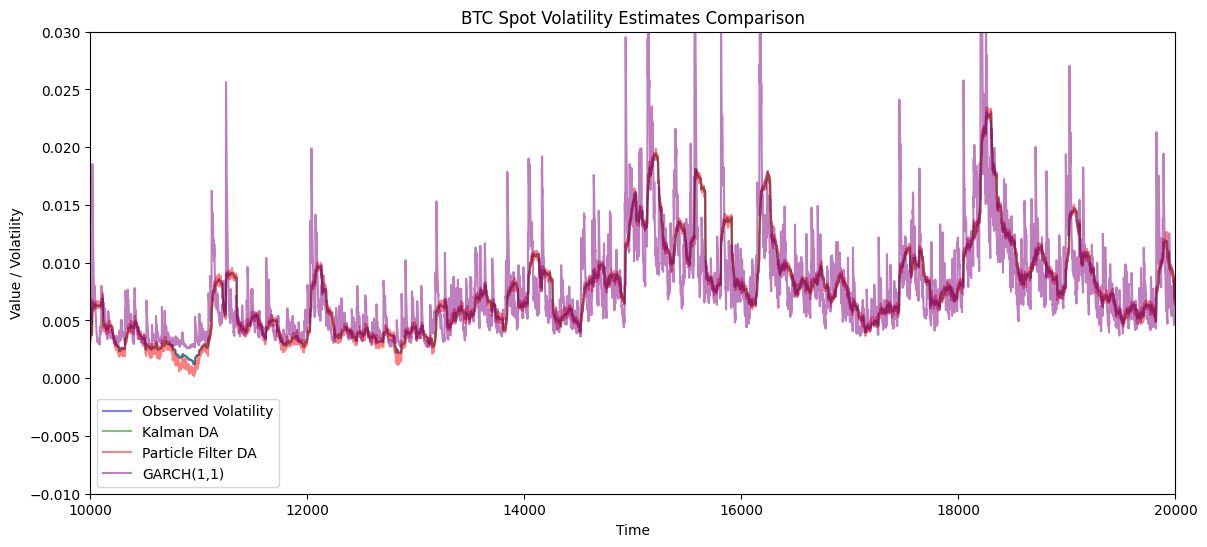

In [80]:
df=pd.read_csv('BTC_spot_full.csv')
df['return'] = df['bam_close'].pct_change().fillna(0)

# Compute rolling-window volatility
df['sigma_obs'] = compute_rolling_volatility(df['return'], window=100)

# Limit data for testing
df = df[10000:]

# Example usage with different filters
sigma_model_naive, sigma_est_naive = generic_DA(df['sigma_obs'], predictor=heston_predictor, combiner=naive_combiner)
df['sigma_est_naive'] = sigma_est_naive

sigma_model_kf, sigma_est_kf = kalman_DA(df['sigma_obs'])
df['sigma_est_kf'] = sigma_est_kf

sigma_model_pf, sigma_est_pf = particle_filter_DA(df['sigma_obs'])
df['sigma_est_pf'] = sigma_est_pf

# Plot results
df[['bam_close', 'sigma_obs', 'sigma_est_naive', 'sigma_est_kf', 'sigma_est_pf']].plot(subplots=True, figsize=(12,10))

plt.show()
from arch import arch_model

# Fit GARCH(1,1) on the returns
returns = df['return']*100  # scale to percent for stability
garch = arch_model(returns, vol='Garch', p=1, q=1, dist='normal')
res = garch.fit(disp='off')

# In-sample conditional volatility
sigma_garch = res.conditional_volatility / 100  # scale back to original
df['sigma_garch'] = sigma_garch.values

plt.figure(figsize=(14,6))

plt.plot(df['sigma_obs'], label='Observed Volatility', color='blue', alpha=0.5)
# plt.plot(df['sigma_est_naive'], label='Naive DA', color='orange')
plt.plot(df['sigma_est_kf'], label='Kalman DA', color='green', alpha=0.5)
plt.plot(df['sigma_est_pf'], label='Particle Filter DA', color='red', alpha=0.5)
plt.plot(df['sigma_garch'], label='GARCH(1,1)', color='purple' ,alpha =0.5)
plt.xlabel('Time')
plt.ylabel('Value / Volatility')
plt.title('BTC Spot Volatility Estimates Comparison')
plt.xlim(10000,20000)
plt.ylim(-0.01,0.03)
plt.legend()
plt.show()

# apply state estimation models